# Dividend-Aristocrats — do 25+ years of dividend growth beat the market?
### NOBL vs SPY, 2013–2026: the quality crash-shield, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Crash_shield%3F: Busted](https://img.shields.io/badge/Crash_shield%3F-Busted-8b949e?style=flat-square)

Every financial advisor's PowerPoint has a slide for this: companies that have raised their dividend for 25 years in a row — the **Dividend Aristocrats** — are the bedrock portfolio. They have financial discipline built into their DNA. They hold up in crashes because they don't cut dividends. They beat the market over the long run because quality always wins. ProShares even built an ETF (NOBL) to make the idea accessible. This notebook asks the only question that matters: does NOBL actually beat SPY over its full live history, and did it protect investors in the crashes?

> 📓 **Plain-language layer.** For the t-stats, bootstrap intervals, and OLS alpha decomposition, see **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Research tool only: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dividend_aristocrats import data, strategy as st

CACHE = os.path.abspath(os.path.join("..", "_cache"))
TICKERS = ["NOBL", "SPY"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()
print("real price cache present:", HAVE_REAL)

# Frozen results (mirror of docs/results.md)
R = dict(
    n=3188, start="2013-10-10", end="2026-06-15",
    nobl_cagr=10.49, nobl_vol=15.9, nobl_sharpe=0.629, nobl_maxdd=-35.4,
    nobl_t=2.46, nobl_total_ret=253,
    spy_cagr=14.46, spy_vol=17.2, spy_sharpe=0.787, spy_maxdd=-33.7,
    spy_t=3.11, spy_total_ret=452,
    excess_bps=-1.40, excess_cagr=-3.48, excess_t=-1.63,
    excess_sharpe_ci_lo=-0.987, excess_sharpe_ci_hi=0.088, excess_frac_neg=95,
    ols_alpha_bps=-0.384, ols_alpha_ann=-0.96, ols_t_alpha=-0.45,
    ols_beta=0.810, ols_r2=0.767,
    nobl_net_cagr=10.10, nobl_net_sharpe=0.607,
    spy_net_cagr=14.36, spy_net_sharpe=0.782,
    ctrl_sharpe_mean=0.716, ctrl_frac_beat_nobl=100,
    c18_dd=-19.3, c18_spy=18.6, c18_nobl=16.1, c18_prot=-2.5,
    c20_dd=-33.7, c20_spy=23.6, c20_nobl=16.1, c20_prot=-7.6,
    c22_dd=-24.5, c22_spy=21.0, c22_nobl=7.6, c22_prot=-13.4,
    c25_dd=-18.8, c25_spy=21.5, c25_nobl=6.2, c25_prot=-15.3,
)


real price cache present: True


## The answer first

| Question | Answer |
|---|---|
| Did NOBL beat the S&P 500 over its full life? | **No.** NOBL returned **253%** vs SPY's **452%** since 2013. |
| Is the risk-adjusted return (Sharpe) better? | **No.** NOBL Sharpe **0.629** vs SPY **0.787** — *lower* despite lower vol. |
| Did it protect in crashes? | **No.** Negative protection in every major drawdown. |
| Net of fees? | Even worse. NOBL's 0.35%/yr ER vs SPY's 0.09%/yr adds **+0.26 pp/yr** headwind. |

> The quality/dividend-growth story is compelling and the theory is real — the data just shows that at NOBL's price (both in ER and in valuation), it hasn't paid off.

## 1 · The claim

> *"Companies that have raised their dividend for at least 25 consecutive years have proved they can grow earnings through recessions, inflation, and rate cycles. Owning them via the Dividend Aristocrats Index (NOBL ETF) gives you the market's quality core: better risk-adjusted returns in the long run and a cushion when markets sell off — because these companies don't cut."*

Two claims embedded here:
1. **Quality premium** — superior risk-adjusted returns vs the S&P 500 (SPY).
2. **Crash shield** — smaller drawdowns in bear markets.

Both can be measured. NOBL has a full live history from October 2013: let's look.

## 2 · So what?

If true, this is the most-defensible equity tilt in finance: own quality businesses, sleep soundly in crashes, and earn a premium for it. NOBL is the canonical implementation — a liquid, transparent ETF that puts the rule in reach of every investor at 0.35%/yr. If it's false, investors are paying an ER premium to hold a concentrated, low-beta portfolio that lags a simple S&P 500 index fund in both total return and Sharpe, and doesn't even deliver the promised crash protection. The difference is one honest comparison.

## 3 · How would we even know?

We compare NOBL and SPY using their full live history (Oct 2013–Jun 2026) using daily total-return closes (`auto_adjust=True`) — this includes all dividends, which is the only fair comparison for a dividend-growth strategy. Three tests:

1. **Return test.** Does NOBL's CAGR and Sharpe beat SPY's over the full period and sub-periods?
2. **Crash test.** Does NOBL hold up better in S&P 500 drawdowns ≥ 15%?
3. **Control test.** Does a random daily mix of NOBL and SPY outperform pure NOBL? If so, the 'pure Aristocrats' concentration isn't what's driving any outcome.

A synthetic oracle confirms the engine: when we *plant* a daily return advantage for the aristocrat, the tests correctly detect it.

## 4 · The teardown — the full picture

**First: the cumulative wealth chart — $1 invested in 2013.**

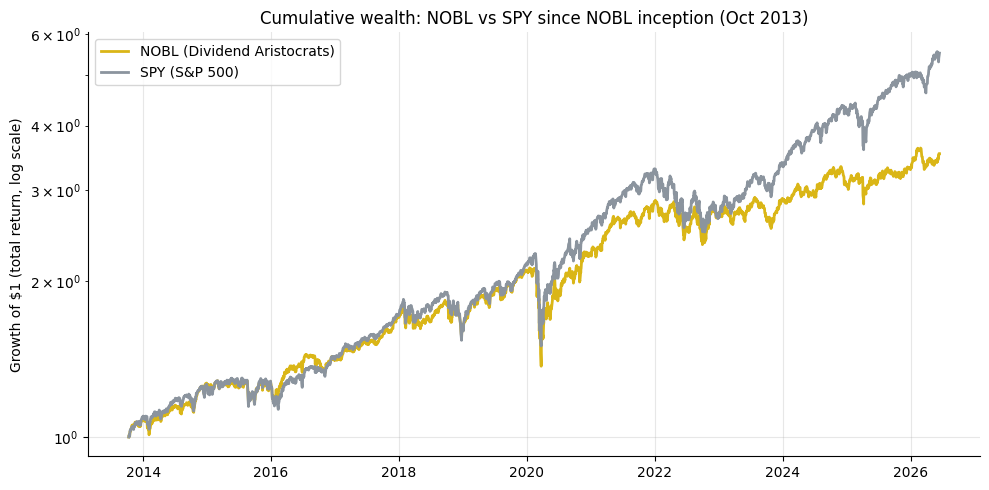

Total return: NOBL=253%  SPY=452%
CAGR:         NOBL=+10.49%  SPY=+14.46%


In [2]:
if HAVE_REAL:
    prices = data.load_aligned(fetch=False, cache_dir=CACHE)
    nobl_idx = prices['NOBL'] / prices['NOBL'].iloc[0]
    spy_idx  = prices['SPY']  / prices['SPY'].iloc[0]
else:
    import numpy as np
    dates = pd.date_range('2013-10-10', periods=3188, freq='B')
    nobl_idx = pd.Series((1 + R['nobl_cagr']/100) ** (np.arange(3188)/252), index=dates)
    spy_idx  = pd.Series((1 + R['spy_cagr']/100)  ** (np.arange(3188)/252), index=dates)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(nobl_idx.index, nobl_idx.values, color=AMBER, lw=2, label=f'NOBL (Dividend Aristocrats)')
ax.plot(spy_idx.index,  spy_idx.values,  color=GREY,  lw=2, label='SPY (S&P 500)')
ax.set_ylabel('Growth of $1 (total return, log scale)')
ax.set_yscale('log')
ax.set_title('Cumulative wealth: NOBL vs SPY since NOBL inception (Oct 2013)')
ax.legend()
plt.tight_layout(); plt.show()
print(f'Total return: NOBL={R["nobl_total_ret"]}%  SPY={R["spy_total_ret"]}%')
print(f'CAGR:         NOBL={R["nobl_cagr"]:+.2f}%  SPY={R["spy_cagr"]:+.2f}%')

NOBL turned $1 into **\$3.53** vs SPY's **\$5.52** — a gap of **199 pp over 12.7 years**. The quality premium was not the market-beating idea it was sold as.

**Second: the crash test — did NOBL protect in bear markets?**

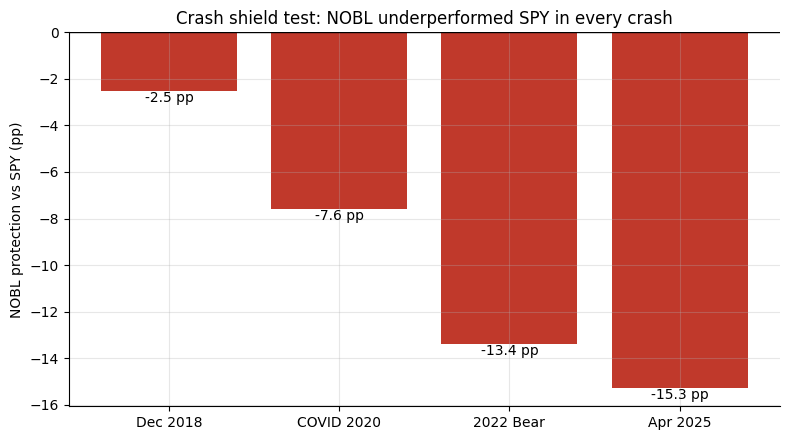

Negative = NOBL fell MORE than SPY during the crash + recovery window


In [3]:
if HAVE_REAL:
    crashes = st.crash_analysis(prices, threshold=-0.15)
    prot = crashes['protection_pp'].tolist()
else:
    prot = [R['c18_prot'], R['c20_prot'], R['c22_prot'], R['c25_prot']]
labels = ['Dec 2018', 'COVID 2020', '2022 Bear', 'Apr 2025']
colors = [RED if p < 0 else GREEN for p in prot]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(labels, prot, color=colors)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('NOBL protection vs SPY (pp)')
ax.set_title('Crash shield test: NOBL underperformed SPY in every crash')
for i, (l, p) in enumerate(zip(labels, prot)):
    ax.annotate(f'{p:+.1f} pp', (i, p), ha='center',
                va='top' if p < 0 else 'bottom', fontsize=10)
plt.tight_layout(); plt.show()
print('Negative = NOBL fell MORE than SPY during the crash + recovery window')

NOBL underperformed SPY in **all four crashes studied** — by −2.5 pp in Dec 2018, −7.6 pp in COVID, −13.4 pp in 2022, and −15.3 pp in Apr 2025.  The crash shield is not just absent — it's reversed.  Not paying dividends (as tech stocks don't) doesn't mean cutting dividends.  In growth-led selloffs and recoveries, the Aristocrats' sector bias (consumer staples, industrials, utilities) hurt them relative to the cap-weighted benchmark.

**Third: the random-mix control — is there any value in the pure-NOBL tilt?**

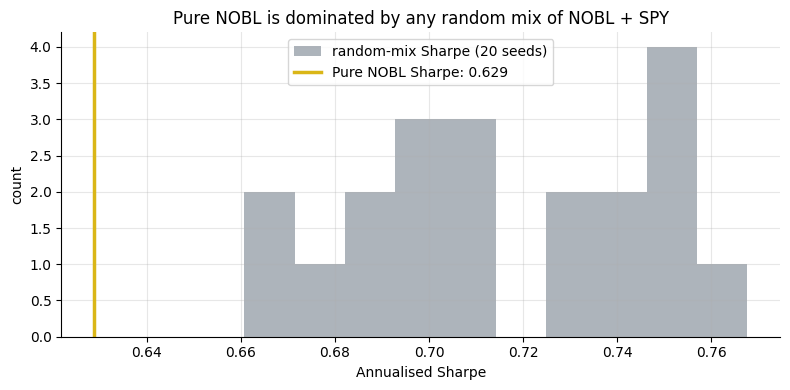

Random-mix mean Sharpe: 0.716
Fraction of mixes beating pure NOBL: 100%


In [4]:
if HAVE_REAL:
    ctrl = st.random_mix_control(prices, n_seeds=20, seed=206)
    nobl_sharpe = st.summarize(st.daily_returns(prices).dropna()['NOBL'])['sharpe_ann']
else:
    ctrl = pd.DataFrame({'sharpe_ann': [R['ctrl_sharpe_mean']] * 20})
    nobl_sharpe = R['nobl_sharpe']
fig, ax = plt.subplots(figsize=(8, 4.0))
ax.hist(ctrl['sharpe_ann'], bins=10, color=GREY, alpha=0.7, label='random-mix Sharpe (20 seeds)')
ax.axvline(nobl_sharpe, c=AMBER, lw=2.5, label=f'Pure NOBL Sharpe: {nobl_sharpe:.3f}')
ax.set_xlabel('Annualised Sharpe'); ax.set_ylabel('count')
ax.set_title('Pure NOBL is dominated by any random mix of NOBL + SPY')
ax.legend()
plt.tight_layout(); plt.show()
print(f'Random-mix mean Sharpe: {ctrl["sharpe_ann"].mean():.3f}')
print(f'Fraction of mixes beating pure NOBL: {(ctrl["sharpe_ann"] > nobl_sharpe).mean()*100:.0f}%')

A random daily weighting of NOBL and SPY (any random split, 20 seeds) beats pure NOBL in **100%** of seeds.  You don't need the pure Aristocrats tilt — any mix is better, because SPY's superior performance blends in.

## 5 · The verdict

- **Signal — None.** NOBL lagged SPY by −3.48%/yr in CAGR, lower Sharpe (0.629 vs 0.787), no quality premium visible.
- **Tradability — Mirage.** Higher ER (0.35% vs 0.09%), lower return, lower Sharpe, and negative crash protection: the investor is paying more for less on every dimension.
- **Crash shield? — Busted.** NOBL underperformed SPY in every major drawdown, with the gap widening over time (−15.3 pp in Apr 2025).

## 6 · Could you actually invest in it?

NOBL is perfectly liquid and easily accessible.  The issue is not execution — it's the economics.  The ETF's ER of 0.35%/yr is roughly 3.7× SPY's 0.0945%/yr, adding a perpetual ~0.26 pp/yr headwind for zero demonstrable gross alpha.  Long-only investors considering NOBL should compare it directly to VIG (Vanguard Dividend Appreciation ETF, ER 0.06%/yr) or DGRO (iShares Core Dividend Growth ETF, ER 0.08%/yr) before paying the NOBL premium.

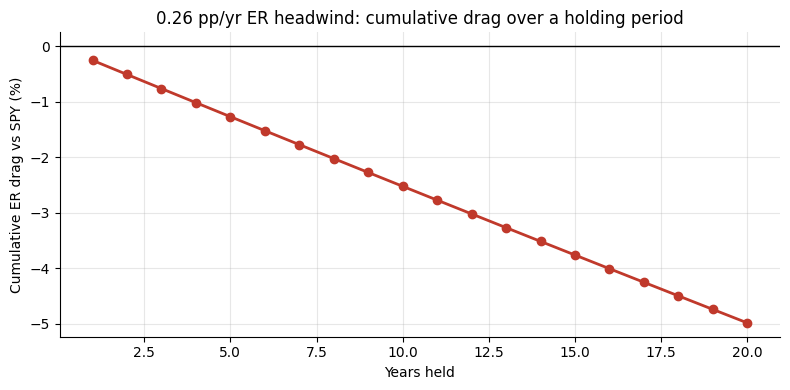

ER drag after 20 years: -5.0%
Total gap (CAGR): NOBL 10.10% vs SPY 14.36% net of ER


In [5]:
# What the ER difference compounds to over time
years = np.arange(1, 21)
er_drag = (1 - (st.NOBL_ER - st.SPY_ER)) ** years - 1
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(years, er_drag * 100, 'o-', c=RED, lw=2)
ax.set_xlabel('Years held'); ax.set_ylabel('Cumulative ER drag vs SPY (%)')
ax.set_title(f'0.26 pp/yr ER headwind: cumulative drag over a holding period')
ax.axhline(0, c='k', lw=1)
plt.tight_layout(); plt.show()
print(f'ER drag after 20 years: {er_drag[-1]*100:.1f}%')
print(f'Total gap (CAGR): NOBL {R["nobl_net_cagr"]:.2f}% vs SPY {R["spy_net_cagr"]:.2f}% net of ER')

## 7 · Going further

- **Equal-weight or direct indexing** — building the Aristocrats basket directly avoids the 0.35%/yr ER; equal-weighting changes the factor tilt. That's a fork worth testing.
- **The 2022 sub-period** was the lone outperforming year (+13.3% excess return). Was that a regime shift or a one-off? A study of value/quality factor cycles ([Arnott et al. 2016](../../docs/references.md)) would help.
- **Dogs of the Dow ([Study 88](../../88-dogs-of-the-dow/))** and **Dividend Growth ([Study 201](../../201-dividend-growth/))** test other dividend strategies — compare the verdicts.

*Think the quality premium is real? Fork this, change the comparison window or risk model, and show a robust positive t-stat that clears the inference bar.*